# 07c · GSE65391 · RNA_array · heatmap of every visit, visits clustered

Reads `modules.rds`, `wgcna_input.rds`, `expression.rds`, `projected_scores.rds` (for the metadata).

**Samples and matrix** as notebook 07b: 972 samples (924 SLE, 48 healthy), hub genes standardised with
the first-visit mean and SD, colours capped at ±2.5.

**Rows are clustered**: Ward's method (`ward.D2`) on Minkowski distance with p = 2, over all 972
samples, tree not cut. The question is descriptive: do samples lie near others with similar disease
activity, near other visits of the same child, or near healthy samples? The annotations show SLEDAI,
stage, nephritis, healthy or SLE, and visit number. The statistical test of within-child against
between-child association is the mixed model of notebook 06b.

**Columns**: genes, ordered by the Ward tree of notebook 07.

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize)})
mods <- readRDS(art("GSE65391", "modules.rds"))
w    <- readRDS(art("GSE65391", "wgcna_input.rds"))
x    <- readRDS(art("GSE65391", "expression.rds"))
m    <- readRDS(art("GSE65391", "projected_scores.rds"))$meta
hub  <- unlist(lapply(mods$hubs, head, 10))
gene_module <- mods$colors[hub]
mu <- colMeans(w$datExpr[, hub]); s <- apply(w$datExpr[, hub], 2, sd)
X  <- t((x$E[hub, rownames(m)] - mu) / s); Xc <- pmin(pmax(X, -2.5), 2.5)
hc_genes <- hclust(dist(t(scale(w$datExpr[, hub])), method = "minkowski", p = 2), method = "ward.D2")
hc_samples <- hclust(dist(X, method = "minkowski", p = 2), method = "ward.D2")
dim(X)

[1] 972 160

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



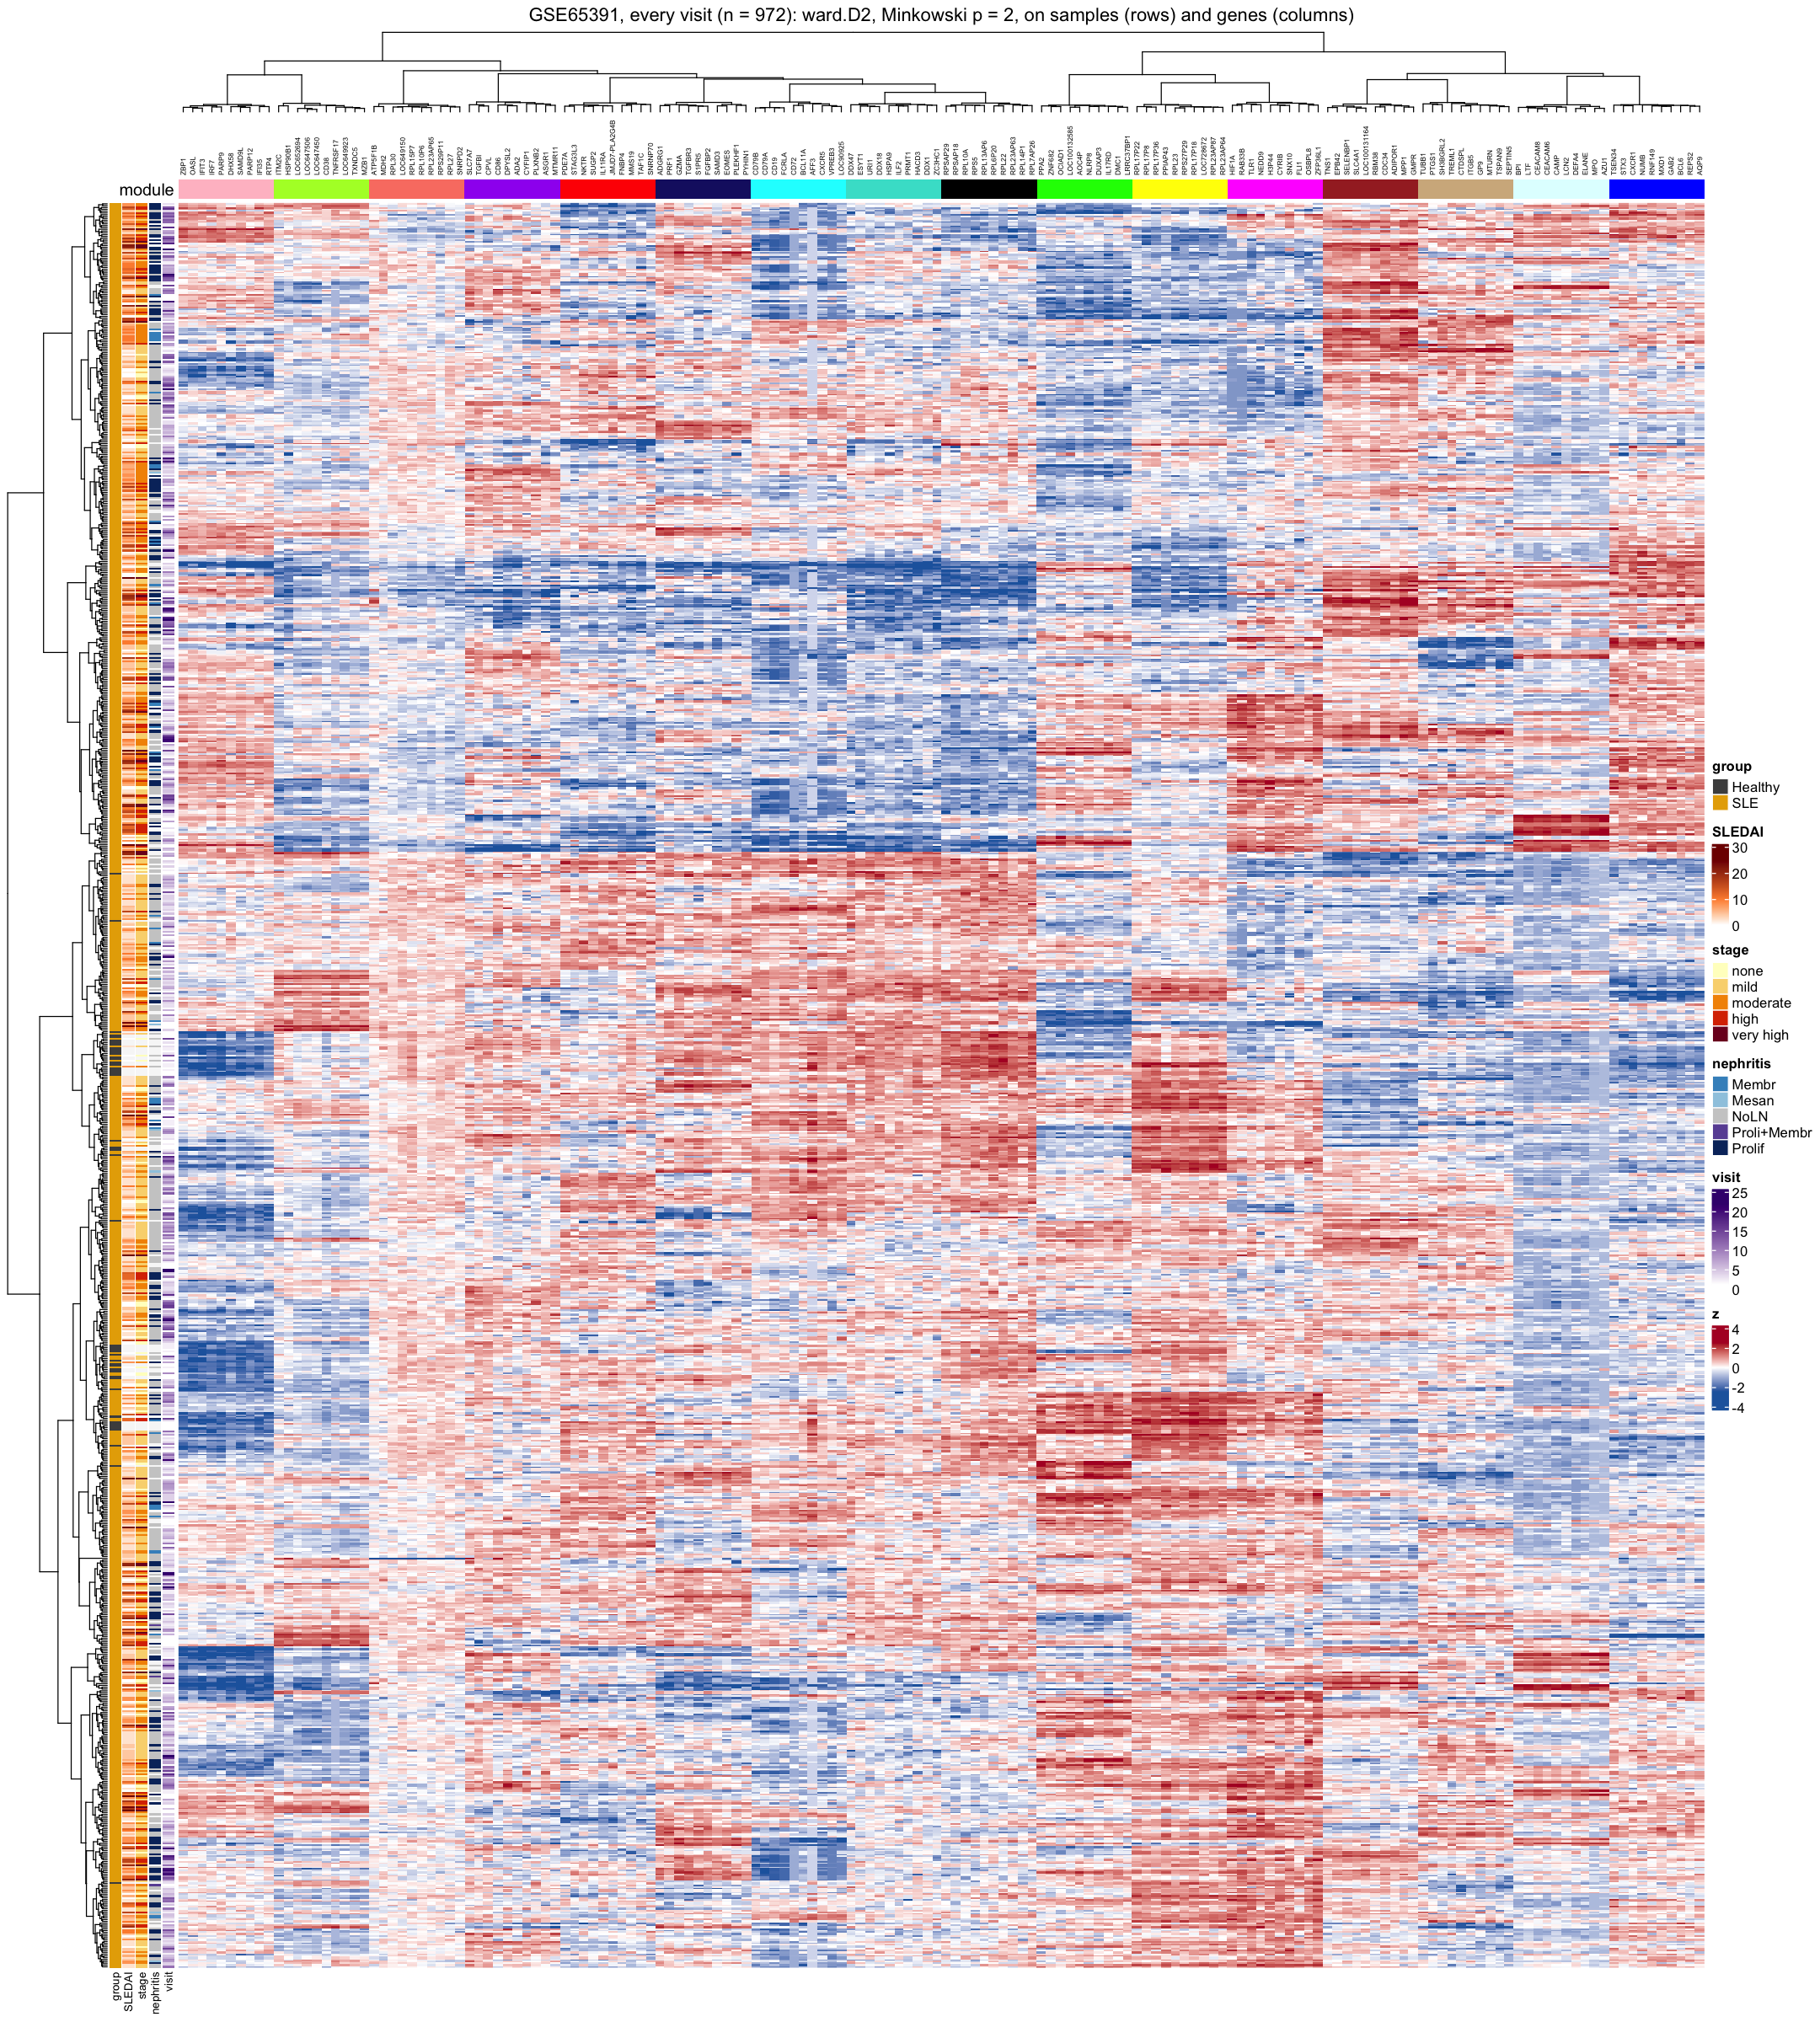

In [2]:
left <- rowAnnotation(
  group = m$disease, SLEDAI = m$sledai, stage = m$stage, nephritis = m$nephritis_class, visit = m$visit,
  na_col = "grey97",
  col = list(group = c(Healthy = "grey30", SLE = "#E6AB02"),
             SLEDAI = colorRamp2(c(0, 10, 25), c("white", "#FD8D3C", "#7F0000")),
             stage = setNames(hcl.colors(5, "YlOrRd", rev = TRUE), levels(m$stage)),
             nephritis = c(NoLN = "grey80", Mesan = "#9ecae1", Membr = "#4292c6", Prolif = "#08306b", "Proli+Membr" = "#6a51a3"),
             visit = colorRamp2(c(1, 22), c("white", "#3f007d"))),
  annotation_name_gp = gpar(fontsize = 8), simple_anno_size = unit(3, "mm"))
options(repr.plot.width = 18, repr.plot.height = 20)
figure <- function() {
  Heatmap(Xc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hc_samples, cluster_columns = hc_genes,
          row_dend_side = "left", column_dend_side = "top",
          row_dend_width = unit(25, "mm"), column_dend_height = unit(20, "mm"),
          show_row_names = FALSE, column_names_side = "top", column_names_gp = gpar(fontsize = 5),
          top_annotation = HeatmapAnnotation(module = gene_module, col = list(module = setNames(unique(gene_module), unique(gene_module))),
                                             show_legend = FALSE, annotation_name_side = "left"),
          left_annotation = left, use_raster = TRUE,
          column_title = "GSE65391, every visit (n = 972): ward.D2, Minkowski p = 2, on samples (rows) and genes (columns)")
}
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE65391", "07c_GSE65391_RNA_array_heatmap_all_visits_clustered_1.png"), width = 18, height = 20, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}